In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def read_csv_file(filename, skiprows=2, num_samples=-1):
    data = pd.read_csv(
        filename,
        delimiter=";",
        skiprows=skiprows,
        decimal=",",
        names=["zeit", "spannung"],
    )

    if num_samples > 0:
        return data[:num_samples]
    return data

read_csv_file("Messung-normal.csv")

,zeit,spannung
0,-25.006666,0.185162
1,-25.001666,0.000000
2,-24.996666,0.000000
3,-24.991666,-0.185162
4,-24.986666,0.185162
...,...,...
9999,24.988333,0.556102
10000,24.993333,0.185162
10001,24.998333,0.370325
10002,25.003333,0.556102


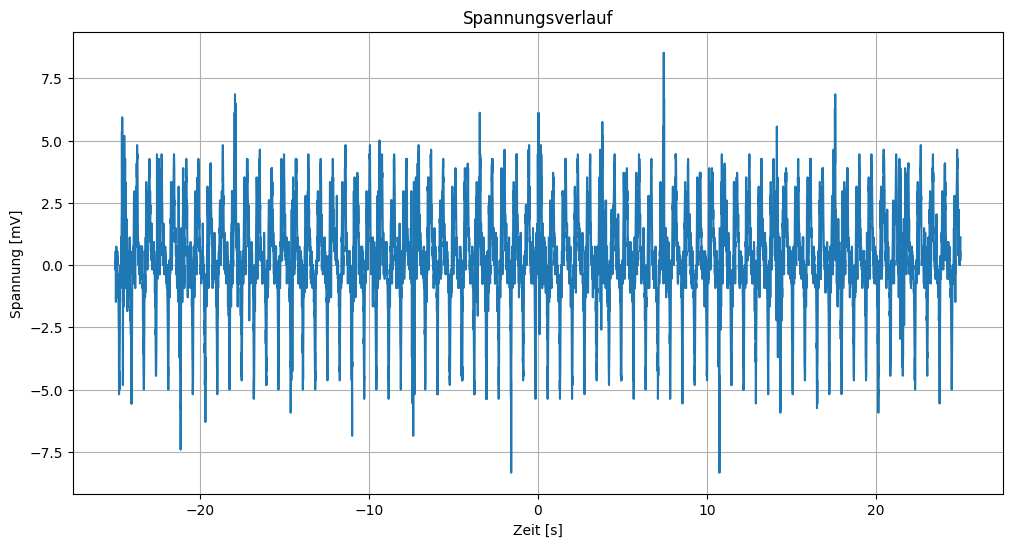

In [4]:
def plot_data(data):
    # Plotten der Daten
    plt.figure(figsize=(12, 6))
    plt.plot(data["zeit"], data["spannung"], label="Messdaten")
    plt.xlabel('Zeit [s]')
    plt.ylabel('Spannung [mV]')
    plt.title('Spannungsverlauf')
    plt.grid(True)
    plt.show()

plot_data(read_csv_file("Messung-normal.csv"))

### Fourier-Transformation

In [8]:
def fourier_transform(data):
    # Berechnung der Fourier-Koeffizienten
    time = data["zeit"]
    signal = data["spannung"]

    M = len(time)
    delta_t = time[1] - time[0]

    amplitude_spectrum = np.abs(np.fft.fft(signal)) / M
    freq = np.fft.fftfreq(M, d=delta_t)[:M // 2]

    sampling_freq = 1 / delta_t
    print(f"Sampling Frequency: {sampling_freq} Hz")
    print(f"Nyquist Frequency: {sampling_freq / 2} Hz")

    return freq, amplitude_spectrum[:M // 2]

fourier_transform(read_csv_file("Messung-normal.csv"))

Sampling Frequency: 199.99999999989768 Hz
Nyquist Frequency: 99.99999999994884 Hz


(array([0.00000000e+00, 1.99920032e-02, 3.99840064e-02, ...,
        9.99400240e+01, 9.99600160e+01, 9.99800080e+01]),
 array([0.37078162, 0.00502547, 0.00117683, ..., 0.00328216, 0.00250585,
        0.00692163]))

Sampling Frequency: 199.99999999989768 Hz
Nyquist Frequency: 99.99999999994884 Hz


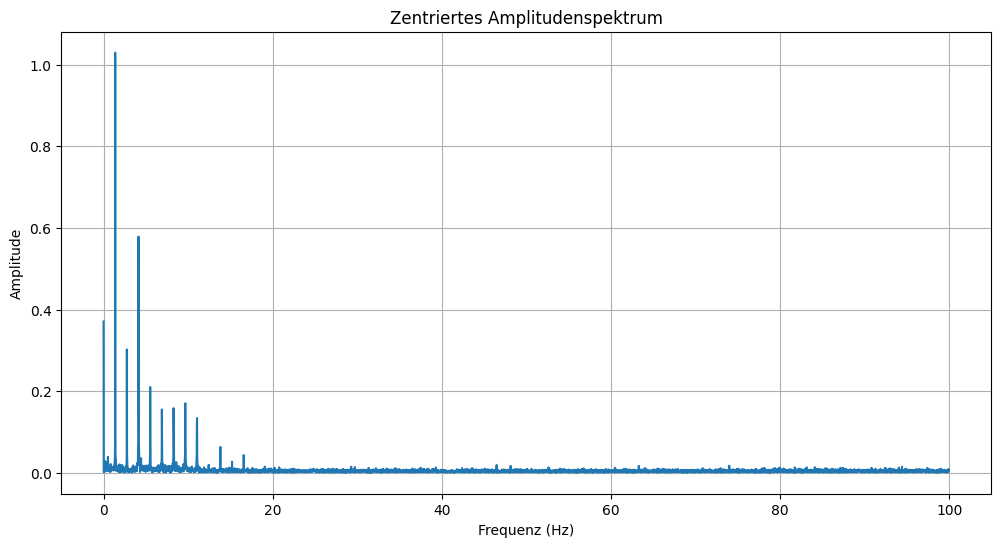

In [ ]:
def plot_fft(freq, amplitude_spectrum):
    plt.figure(figsize=(12, 6))
    plt.plot(freq, amplitude_spectrum)
    plt.title("Zentriertes Amplitudenspektrum")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

data = read_csv_file("Messung-normal.csv")
freq, amplitude_spectrum = fourier_transform(data)
plot_fft(freq, amplitude_spectrum)